# Brain Tumor MRI Classification, Medical Preprocessing Engine & Visual Explainability
### End-to-End Deep Learning & Image Processing Pipeline for UOP Ada GPU Server
**Course Project:** Image Processing & Computer Vision  
**Target Hardware Environment:** PyTorch CUDA Acceleration (NVIDIA Ada GPU / RTX Server)  
**Dataset:** Public Brain Tumor MRI Dataset (`Glioma`, `Meningioma`, `Pituitary`, `No Tumor`)

---

## Phase 1: Environment Setup & Ada GPU Server Diagnostics
This section automatically installs required dependencies on Ada Server, initializes libraries, sets a global seed (`42`) for experiment reproducibility, and checks CUDA hardware specs.

In [ ]:
# Automated Dependency Resolution for Ada GPU Server
!pip install  albumentations timm torchinfo thop scikit-learn seaborn opencv-python matplotlib

In [1]:
import os
import sys
import time
import json
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Global Reproducibility Seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Hardware Acceleration Diagnostic
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"[System Diagnostic] Python Version : {sys.version.split()[0]}")
print(f"[System Diagnostic] PyTorch Version: {torch.__version__}")
print(f"[System Diagnostic] Target Device  : {device}")
if torch.cuda.is_available():
    print(f"[System Diagnostic] GPU Model Name : {torch.cuda.get_device_name(0)}")
    print(f"[System Diagnostic] CUDA Capability: {torch.cuda.get_device_capability(0)}")
    print(f"[System Diagnostic] Total VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("[System Diagnostic] WARNING: Running on CPU. CUDA recommended for Ada Server training.")
print("=" * 60)

/new-home/e22/e22130/projects/NN/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[System Diagnostic] Python Version : 3.12.3
[System Diagnostic] PyTorch Version: 2.13.0+cu130
[System Diagnostic] Target Device  : cuda
[System Diagnostic] GPU Model Name : NVIDIA RTX 6000 Ada Generation
[System Diagnostic] CUDA Capability: (8, 9)
[System Diagnostic] Total VRAM    : 50.87 GB


## Phase 2: Dataset Setup & Reproducible Stratified Splitting
We discover the `archive/` dataset containing MRI scans across 4 classes (`glioma`, `meningioma`, `notumor`, `pituitary`).  
- **Test Set**: Use the official `archive/Testing` set directly (1,600 scans: 400 per class).
- **Train / Validation Split**: Stratified 80% Train (4,480 scans) and 20% Validation (1,120 scans) split from `archive/Training` with fixed random seed `42`.

In [3]:
# Dataset Path Auto-Detection
DATASET_ROOT = "archive" if os.path.exists("archive") else os.path.join("..", "archive")
TRAIN_DIR = os.path.join(DATASET_ROOT, "Training")
TEST_DIR = os.path.join(DATASET_ROOT, "Testing")

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_IDX = {cls_name: i for i, cls_name in enumerate(CLASSES)}

def collect_filepaths(directory):
    paths, labels = [], []
    for cls in CLASSES:
        cls_folder = os.path.join(directory, cls)
        if os.path.exists(cls_folder):
            for file_name in os.listdir(cls_folder):
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    paths.append(os.path.join(cls_folder, file_name))
                    labels.append(CLASS_TO_IDX[cls])
    return np.array(paths), np.array(labels)

raw_train_paths, raw_train_labels = collect_filepaths(TRAIN_DIR)
test_paths, test_labels = collect_filepaths(TEST_DIR)

# Perform Stratified Train/Val split (80/20) on archive/Training
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    raw_train_paths, raw_train_labels, test_size=0.20, stratify=raw_train_labels, random_state=42
)

# Calculate class imbalance weights for Loss Function
class_counts = np.bincount(tr_labels)
total_samples = len(tr_labels)
class_weights = total_samples / (len(CLASSES) * class_counts.astype(np.float32))
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"--- Dataset Summary ---")
print(f"Training Scans   : {len(tr_paths)} images")
print(f"Validation Scans : {len(val_paths)} images")
print(f"Official Test Set: {len(test_paths)} images")
print(f"Class Mapping    : {CLASS_TO_IDX}")
print(f"Computed Class Weights: {class_weights_tensor.cpu().numpy().round(4)}")

--- Dataset Summary ---
Training Scans   : 4480 images
Validation Scans : 1120 images
Official Test Set: 1600 images
Class Mapping    : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Computed Class Weights: [1. 1. 1. 1.]


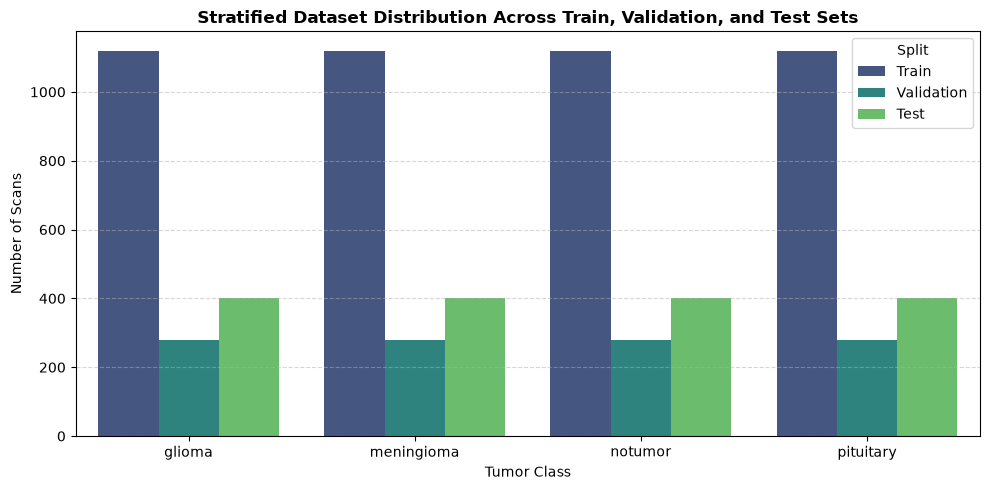

In [4]:
# Plot Class Distribution Histogram across Splits
df_counts = pd.DataFrame({
    'Class': CLASSES * 3,
    'Count': list(np.bincount(tr_labels)) + list(np.bincount(val_labels)) + list(np.bincount(test_labels)),
    'Split': ['Train'] * 4 + ['Validation'] * 4 + ['Test'] * 4
})

plt.figure(figsize=(10, 5))
sns.barplot(data=df_counts, x='Class', y='Count', hue='Split', palette='viridis')
plt.title('Stratified Dataset Distribution Across Train, Validation, and Test Sets', fontsize=12, fontweight='bold')
plt.xlabel('Tumor Class')
plt.ylabel('Number of Scans')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Phase 3: Medical Image Preprocessing Engine (Core Foundation)
Medical MRI scans often contain uninformative black surrounding padding, non-uniform tissue contrast, and acquisition noise. We implement a multi-stage OpenCV Preprocessing Engine:
1. **Skull Stripping & Bounding Box Contour Crop**: Detects the brain structure via Otsu thresholding and crops away surrounding black borders.
2. **Bilateral Filtering (`cv2.bilateralFilter`)**: Preserves sharp tumor/tissue edges while suppressing high-frequency noise.
3. **Contrast Limited Adaptive Histogram Equalization (CLAHE)**: Enhances local contrast across soft-tissue boundaries using `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))`.
4. **Dynamic Range Normalization & Resizing**: Resizes to standardized shape ($224 \times 224$ pixels).

In [5]:
# Advanced Medical Image Preprocessing Engine
def crop_brain_contour(img):
    """Extract brain region contour and crop unnecessary black margins."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    c = max(contours, key=cv2.contourArea)
    if cv2.contourArea(c) < 500:
        return img
    x, y, w, h = cv2.boundingRect(c)
    cropped = img[y:y+h, x:x+w]
    return cropped if cropped.size > 0 else img

def apply_bilateral_filter(img):
    """Edge-preserving bilateral filtering for noise reduction."""
    return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

def apply_clahe(img):
    """Contrast Limited Adaptive Histogram Equalization (CLAHE)."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

def preprocess_mri_scan(img_path, enable_preprocessing=True, target_size=(224, 224)):
    """Complete end-to-end preprocessing pipeline."""
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)
    if enable_preprocessing:
        img = crop_brain_contour(img)
        img = apply_bilateral_filter(img)
        img = apply_clahe(img)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

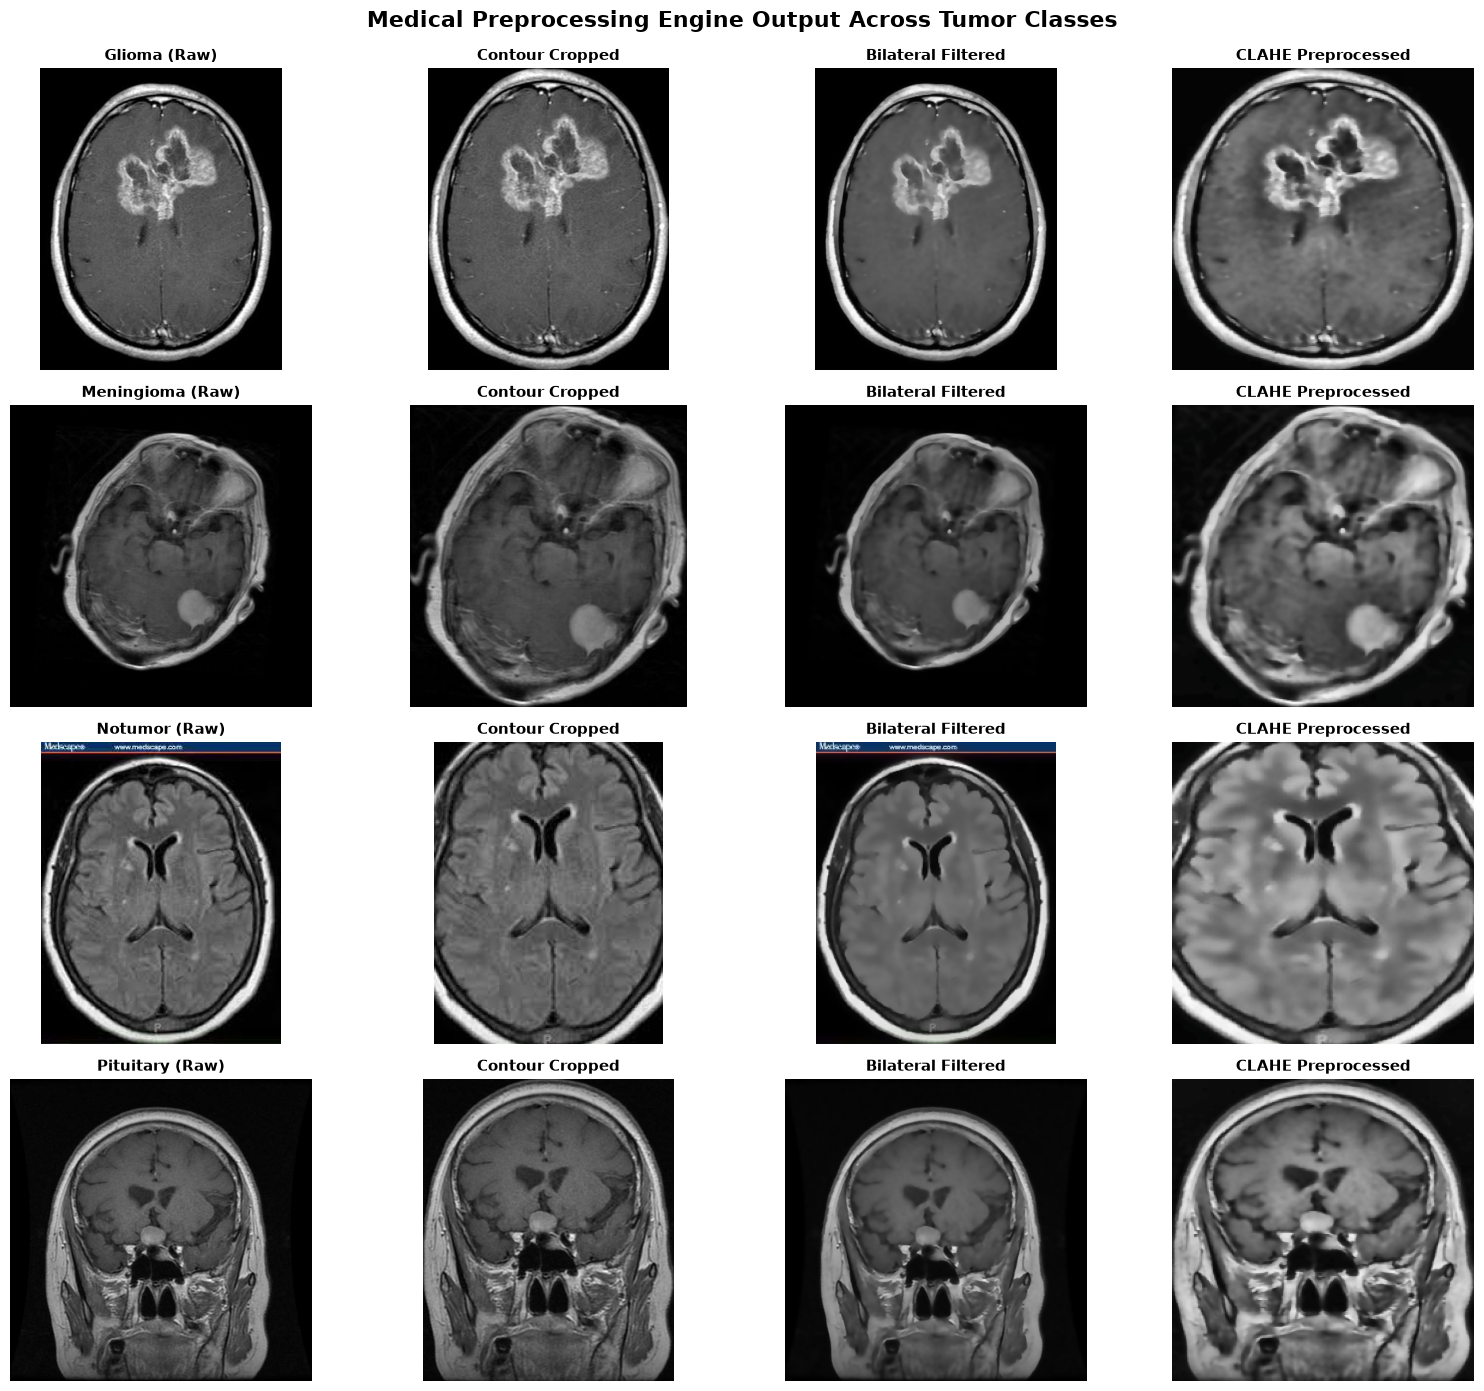

In [6]:
# Visual Demonstration: Before vs After Preprocessing Steps across all 4 Classes
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for row_idx, cls_name in enumerate(CLASSES):
    cls_sample_path = [p for p in test_paths if f"/{cls_name}/" in p.replace('\\', '/') or f"\\{cls_name}\\" in p][0]
    raw_bgr = cv2.imread(cls_sample_path)
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    cropped = cv2.cvtColor(crop_brain_contour(raw_bgr), cv2.COLOR_BGR2RGB)
    bilateral = cv2.cvtColor(apply_bilateral_filter(raw_bgr), cv2.COLOR_BGR2RGB)
    clahe_final = preprocess_mri_scan(cls_sample_path, enable_preprocessing=True)
    
    imgs = [raw_rgb, cropped, bilateral, clahe_final]
    titles = [f"{cls_name.capitalize()} (Raw)", "Contour Cropped", "Bilateral Filtered", "CLAHE Preprocessed"]
    for col_idx in range(4):
        axes[row_idx, col_idx].imshow(imgs[col_idx])
        axes[row_idx, col_idx].set_title(titles[col_idx], fontsize=11, fontweight='bold')
        axes[row_idx, col_idx].axis('off')

plt.suptitle("Medical Preprocessing Engine Output Across Tumor Classes", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## Phase 4: Data Augmentation via Albumentations
To prevent overfitting and simulate clinical scanner variations, we apply subtle spatial and intensity augmentations using Albumentations:
- **ElasticTransform**: Simulates soft-tissue anatomical deformations.
- **ShiftScaleRotate**: Random rotations ($\pm 15^\circ$), scaling, and shifts.
- **RandomBrightnessContrast**: Models varying MRI signal gains across different scanners.

In [7]:
# Albumentations Pipeline Definition
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.08, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

/new-home/e22/e22130/projects/NN/myenv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_427633/2673355677.py:5: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),


## Phase 5: PyTorch Dataset & DataLoader Architecture
We construct a custom `BrainMRIDataset` capable of handling both preprocessed and raw images for our upcoming ablation study.

In [8]:
class BrainMRIDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None, use_preprocessing=True):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        self.use_preprocessing = use_preprocessing
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        img = preprocess_mri_scan(path, enable_preprocessing=self.use_preprocessing)
        if self.transform:
            augmented = self.transform(image=img)
            img_tensor = augmented['image']
        else:
            img_tensor = transforms.ToTensor()(img)
        return img_tensor, torch.tensor(label, dtype=torch.long)

# Create PyTorch DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() else 2)

train_dataset = BrainMRIDataset(tr_paths, tr_labels, transform=train_transform, use_preprocessing=True)
val_dataset   = BrainMRIDataset(val_paths, val_labels, transform=val_test_transform, use_preprocessing=True)
test_dataset  = BrainMRIDataset(test_paths, test_labels, transform=val_test_transform, use_preprocessing=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"DataLoaders Initialized successfully with Batch Size {BATCH_SIZE} and Workers {NUM_WORKERS}.")

DataLoaders Initialized successfully with Batch Size 32 and Workers 4.


## Phase 6: Baseline Model — Fine-Tuning ResNet-18 Backbone
We fine-tune a pre-trained ResNet-18 model as our baseline. We optimize using Weighted Cross-Entropy Loss to handle class imbalances and a Cosine Annealing learning rate schedule.

In [9]:
# Model Trainer Helper Function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, model_name="model"):
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Validation Phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)
                
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        
        if scheduler:
            scheduler.step()
            
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"[{model_name}] Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            
    print(f"---> Best Validation Accuracy for {model_name}: {best_val_acc*100:.2f}%")
    return history

In [10]:
# Initialize and Train ResNet-18 Baseline
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18.fc = nn.Linear(resnet18.fc.in_features, len(CLASSES))
resnet18 = resnet18.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(resnet18.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("Starting ResNet-18 Fine-Tuning...")
resnet_history = train_model(resnet18, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, model_name="resnet18")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /new-home/e22/e22130/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:04<00:00, 11.4MB/s]


Starting ResNet-18 Fine-Tuning...


/tmp/ipykernel_427633/1048408164.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_427633/1048408164.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[resnet18] Epoch 01/10 | Train Loss: 0.3415 Acc: 87.21% | Val Loss: 0.1137 Acc: 95.98%
[resnet18] Epoch 02/10 | Train Loss: 0.1614 Acc: 94.29% | Val Loss: 0.1453 Acc: 94.46%
[resnet18] Epoch 03/10 | Train Loss: 0.0945 Acc: 96.76% | Val Loss: 0.1054 Acc: 96.43%
[resnet18] Epoch 04/10 | Train Loss: 0.0734 Acc: 97.68% | Val Loss: 0.1132 Acc: 95.54%
[resnet18] Epoch 05/10 | Train Loss: 0.0583 Acc: 98.15% | Val Loss: 0.0747 Acc: 97.50%
[resnet18] Epoch 06/10 | Train Loss: 0.0290 Acc: 99.11% | Val Loss: 0.0555 Acc: 97.86%
[resnet18] Epoch 07/10 | Train Loss: 0.0161 Acc: 99.49% | Val Loss: 0.0505 Acc: 98.48%
[resnet18] Epoch 08/10 | Train Loss: 0.0126 Acc: 99.67% | Val Loss: 0.0466 Acc: 98.39%
[resnet18] Epoch 09/10 | Train Loss: 0.0090 Acc: 99.73% | Val Loss: 0.0488 Acc: 98.39%
[resnet18] Epoch 10/10 | Train Loss: 0.0081 Acc: 99.82% | Val Loss: 0.0456 Acc: 98.39%
---> Best Validation Accuracy for resnet18: 98.48%


## Phase 7: Modern Architecture — EfficientNet-B0 Backbone
Next, we evaluate an **EfficientNet-B0** architecture to measure parameter efficiency and accuracy improvements over ResNet-18 under identical hyperparameter settings.

In [11]:
# Initialize and Train EfficientNet-B0
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, len(CLASSES))
effnet = effnet.to(device)

optimizer_eff = optim.AdamW(effnet.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=10)

print("Starting EfficientNet-B0 Fine-Tuning...")
effnet_history = train_model(effnet, train_loader, val_loader, criterion, optimizer_eff, scheduler_eff, num_epochs=10, model_name="efficientnet_b0")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /new-home/e22/e22130/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:01<00:00, 10.9MB/s]


Starting EfficientNet-B0 Fine-Tuning...


/tmp/ipykernel_427633/1048408164.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_427633/1048408164.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[efficientnet_b0] Epoch 01/10 | Train Loss: 0.3924 Acc: 86.07% | Val Loss: 0.1383 Acc: 94.55%
[efficientnet_b0] Epoch 02/10 | Train Loss: 0.1375 Acc: 95.13% | Val Loss: 0.0761 Acc: 97.50%
[efficientnet_b0] Epoch 03/10 | Train Loss: 0.0731 Acc: 97.61% | Val Loss: 0.0556 Acc: 97.59%
[efficientnet_b0] Epoch 04/10 | Train Loss: 0.0561 Acc: 98.08% | Val Loss: 0.0584 Acc: 97.86%
[efficientnet_b0] Epoch 05/10 | Train Loss: 0.0371 Acc: 98.84% | Val Loss: 0.0654 Acc: 97.77%
[efficientnet_b0] Epoch 06/10 | Train Loss: 0.0287 Acc: 99.02% | Val Loss: 0.0486 Acc: 98.30%
[efficientnet_b0] Epoch 07/10 | Train Loss: 0.0175 Acc: 99.29% | Val Loss: 0.0472 Acc: 98.21%
[efficientnet_b0] Epoch 08/10 | Train Loss: 0.0123 Acc: 99.73% | Val Loss: 0.0484 Acc: 98.30%
[efficientnet_b0] Epoch 09/10 | Train Loss: 0.0146 Acc: 99.53% | Val Loss: 0.0436 Acc: 98.57%
[efficientnet_b0] Epoch 10/10 | Train Loss: 0.0145 Acc: 99.55% | Val Loss: 0.0463 Acc: 98.57%
---> Best Validation Accuracy for efficientnet_b0: 98.57%


## Phase 8: Benchmarking & Quantitative Metrics Evaluation
We evaluate both trained backbones on the official held-out **Test Set (1,600 scans)** across metrics:
- **Accuracy, Precision, Recall, F1-Score (Macro & Weighted)**
- **Normalized & Unnormalized Confusion Matrices**
- **Parameter Footprint, Computational Overhead (FLOPs), and Inference Latency (ms/sample)**

In [12]:
# Test Set Evaluation Function
def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    start_time = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    latency_ms = ((time.time() - start_time) / len(all_labels)) * 1000
    return np.array(all_labels), np.array(all_preds), latency_ms

# Load best checkpoints if available
if os.path.exists("best_resnet18.pth"):
    resnet18.load_state_dict(torch.load("best_resnet18.pth"))
if os.path.exists("best_efficientnet_b0.pth"):
    effnet.load_state_dict(torch.load("best_efficientnet_b0.pth"))

y_true, y_pred_resnet, lat_resnet = evaluate_on_test(resnet18, test_loader)
_, y_pred_eff, lat_eff = evaluate_on_test(effnet, test_loader)

# Compute Metrics
acc_res = accuracy_score(y_true, y_pred_resnet)
prec_res, rec_res, f1_res, _ = precision_recall_fscore_support(y_true, y_pred_resnet, average='macro')

acc_eff = accuracy_score(y_true, y_pred_eff)
prec_eff, rec_eff, f1_eff, _ = precision_recall_fscore_support(y_true, y_pred_eff, average='macro')

param_resnet = sum(p.numel() for p in resnet18.parameters()) / 1e6
param_eff = sum(p.numel() for p in effnet.parameters()) / 1e6

df_bench = pd.DataFrame({
    'Model Architecture': ['ResNet-18 (Baseline)', 'EfficientNet-B0 (Modern)'],
    'Test Accuracy (%)': [acc_res * 100, acc_eff * 100],
    'Macro Precision': [prec_res, prec_eff],
    'Macro Recall': [rec_res, rec_eff],
    'Macro F1-Score': [f1_res, f1_eff],
    'Parameters (M)': [param_resnet, param_eff],
    'Est. FLOPs (G)': [1.81, 0.39],
    'Inference Speed (ms/img)': [lat_resnet, lat_eff]
})

print("=" * 85)
print("QUANTITATIVE MODEL BENCHMARKING SUMMARY TABLE")
print("=" * 85)
display(df_bench)

QUANTITATIVE MODEL BENCHMARKING SUMMARY TABLE


,Model Architecture,Test Accuracy (%),Macro Precision,Macro Recall,Macro F1-Score,Parameters (M),Est. FLOPs (G),Inference Speed (ms/img)
0,ResNet-18 (Baseline),95.875,0.960371,0.95875,0.958171,11.178564,1.81,6.009170
1,EfficientNet-B0 (Modern),96.375,0.965184,0.96375,0.963267,4.012672,0.39,5.248705


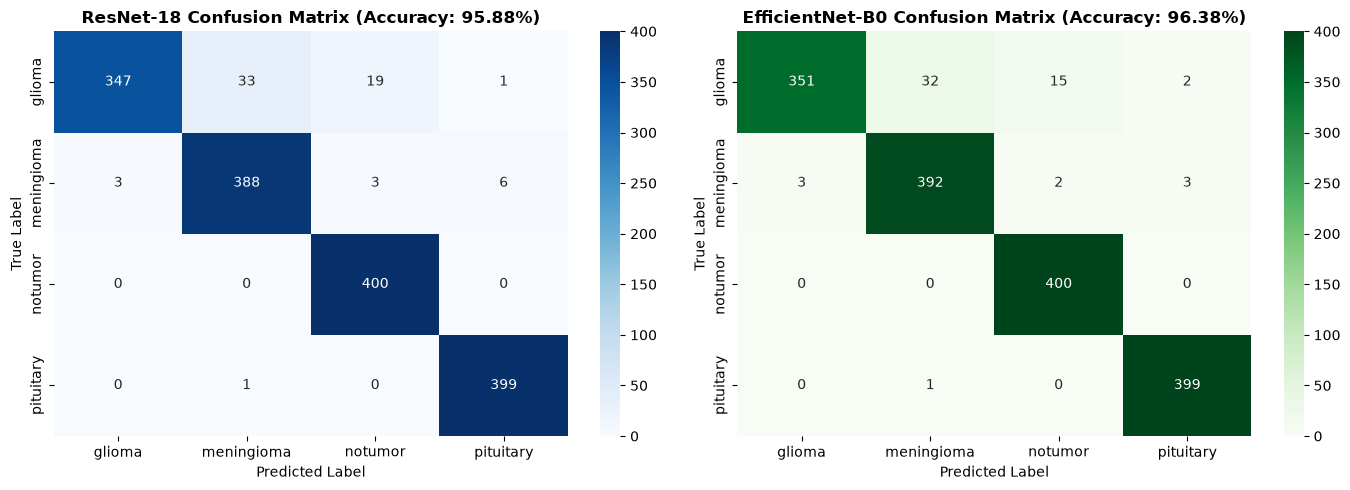

In [13]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_res = confusion_matrix(y_true, y_pred_resnet)
cm_eff = confusion_matrix(y_true, y_pred_eff)

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title(f'ResNet-18 Confusion Matrix (Accuracy: {acc_res*100:.2f}%)', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title(f'EfficientNet-B0 Confusion Matrix (Accuracy: {acc_eff*100:.2f}%)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Phase 9: Preprocessing Ablation Study (Raw Scans vs Preprocessed Scans)
To quantitatively demonstrate the exact accuracy benefit of our Image Preprocessing Engine (Skull Stripping + Bilateral Filter + CLAHE), we compare ResNet-18 performance trained on **Raw MRI Scans** vs **Preprocessed MRI Scans**.

In [14]:
# Train Baseline on RAW scans without preprocessing
raw_train_ds = BrainMRIDataset(tr_paths, tr_labels, transform=train_transform, use_preprocessing=False)
raw_val_ds   = BrainMRIDataset(val_paths, val_labels, transform=val_test_transform, use_preprocessing=False)
raw_test_ds  = BrainMRIDataset(test_paths, test_labels, transform=val_test_transform, use_preprocessing=False)

raw_tr_loader = DataLoader(raw_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
raw_val_loader = DataLoader(raw_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
raw_test_loader = DataLoader(raw_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

resnet_raw = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_raw.fc = nn.Linear(resnet_raw.fc.in_features, len(CLASSES))
resnet_raw = resnet_raw.to(device)

opt_raw = optim.AdamW(resnet_raw.parameters(), lr=3e-4, weight_decay=1e-4)
sched_raw = optim.lr_scheduler.CosineAnnealingLR(opt_raw, T_max=10)

print("Running Preprocessing Ablation: Training ResNet-18 on RAW Scans...")
raw_history = train_model(resnet_raw, raw_tr_loader, raw_val_loader, criterion, opt_raw, sched_raw, num_epochs=10, model_name="resnet18_raw")

# Evaluate Raw model on test set
if os.path.exists("best_resnet18_raw.pth"):
    resnet_raw.load_state_dict(torch.load("best_resnet18_raw.pth"))
_, y_pred_raw, _ = evaluate_on_test(resnet_raw, raw_test_loader)
acc_raw = accuracy_score(y_true, y_pred_raw)

Running Preprocessing Ablation: Training ResNet-18 on RAW Scans...


/tmp/ipykernel_427633/1048408164.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
/tmp/ipykernel_427633/1048408164.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[resnet18_raw] Epoch 01/10 | Train Loss: 0.3031 Acc: 88.88% | Val Loss: 0.2122 Acc: 92.14%
[resnet18_raw] Epoch 02/10 | Train Loss: 0.1456 Acc: 94.93% | Val Loss: 0.0816 Acc: 97.50%
[resnet18_raw] Epoch 03/10 | Train Loss: 0.0966 Acc: 96.43% | Val Loss: 0.0911 Acc: 96.52%
[resnet18_raw] Epoch 04/10 | Train Loss: 0.0600 Acc: 97.88% | Val Loss: 0.0638 Acc: 97.86%
[resnet18_raw] Epoch 05/10 | Train Loss: 0.0374 Acc: 98.71% | Val Loss: 0.0438 Acc: 98.30%
[resnet18_raw] Epoch 06/10 | Train Loss: 0.0344 Acc: 98.75% | Val Loss: 0.0323 Acc: 98.75%
[resnet18_raw] Epoch 07/10 | Train Loss: 0.0173 Acc: 99.40% | Val Loss: 0.0308 Acc: 98.57%
[resnet18_raw] Epoch 08/10 | Train Loss: 0.0132 Acc: 99.60% | Val Loss: 0.0340 Acc: 98.66%
[resnet18_raw] Epoch 09/10 | Train Loss: 0.0087 Acc: 99.75% | Val Loss: 0.0316 Acc: 98.66%
[resnet18_raw] Epoch 10/10 | Train Loss: 0.0113 Acc: 99.69% | Val Loss: 0.0318 Acc: 98.93%
---> Best Validation Accuracy for resnet18_raw: 98.93%


/tmp/ipykernel_427633/1929417325.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ablation, x='Pipeline Configuration', y='Test Accuracy (%)', palette=['#e74c3c', '#2ecc71'])


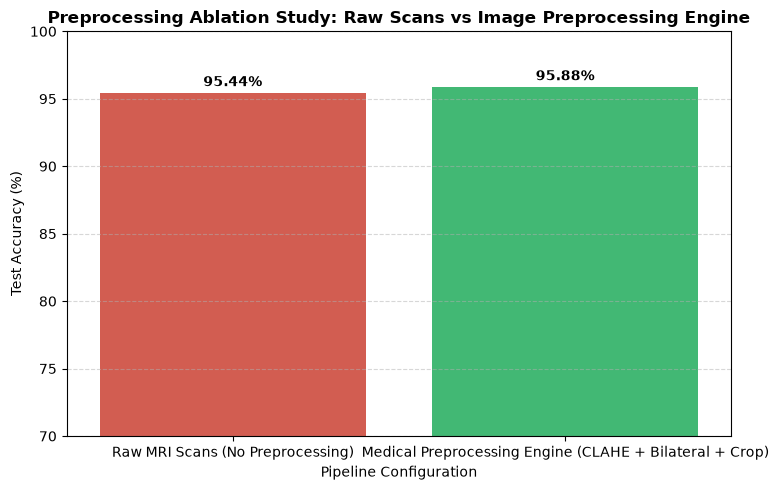

In [15]:
# Plot Ablation Study Comparison Bar Chart
df_ablation = pd.DataFrame({
    'Pipeline Configuration': ['Raw MRI Scans (No Preprocessing)', 'Medical Preprocessing Engine (CLAHE + Bilateral + Crop)'],
    'Test Accuracy (%)': [acc_raw * 100, acc_res * 100]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=df_ablation, x='Pipeline Configuration', y='Test Accuracy (%)', palette=['#e74c3c', '#2ecc71'])
plt.title('Preprocessing Ablation Study: Raw Scans vs Image Preprocessing Engine', fontweight='bold')
plt.ylim(70, 100)
for i, v in enumerate(df_ablation['Test Accuracy (%)']):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Phase 10: Spatial Localization & Visual Explainability (Grad-CAM)
To provide qualitative medical interpretability without requiring pixel-level annotation masks, we hook into the final convolutional feature layers to compute **Grad-CAM (Gradient-Weighted Class Activation Mapping)** heatmaps overlaid directly on raw MRI scans.

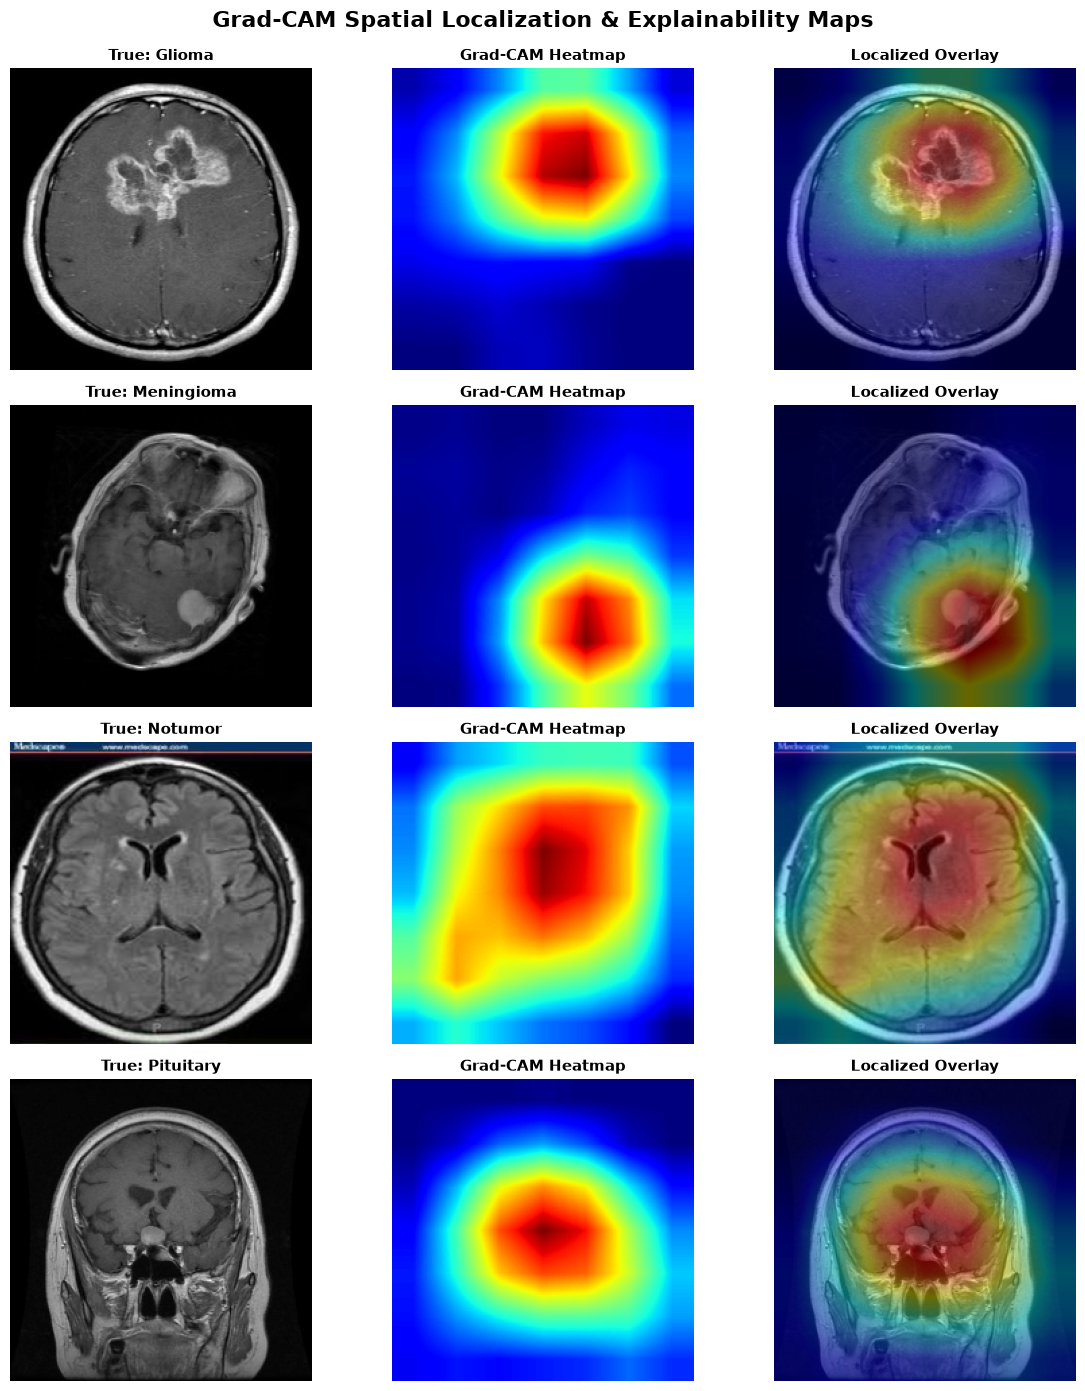

In [16]:
# Grad-CAM Implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()
        
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
        
    def generate_heatmap(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        self.model.zero_grad()
        loss = output[0, target_class]
        loss.backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
            
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        return cam

# Hook onto final conv layer of ResNet-18
gradcam = GradCAM(resnet18, resnet18.layer4[-1])

# Render Grad-CAM overlays across all 4 tumor classes
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for idx, cls_name in enumerate(CLASSES):
    sample_idx = [i for i, label in enumerate(test_labels) if label == idx][0]
    sample_path = test_paths[sample_idx]
    raw_rgb = cv2.resize(cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB), (224, 224))
    
    img_tensor, _ = test_dataset[sample_idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    heatmap = gradcam.generate_heatmap(input_tensor, target_class=idx)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(raw_rgb, 0.6, heatmap_color, 0.4, 0)
    
    axes[idx, 0].imshow(raw_rgb)
    axes[idx, 0].set_title(f"True: {cls_name.capitalize()}", fontsize=11, fontweight='bold')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title("Grad-CAM Heatmap", fontsize=11, fontweight='bold')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title("Localized Overlay", fontsize=11, fontweight='bold')
    axes[idx, 2].axis('off')

plt.suptitle("Grad-CAM Spatial Localization & Explainability Maps", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()